# 🎾 Khám Phá, Trực Quan Hóa & Tiền Xử Lý Dữ Liệu Vạch Sân (Court Keypoints Preprocessing)

Notebook này trực quan hóa toàn bộ quy trình tiền xử lý 14 điểm mốc vạch sân tennis cho mạng nơ-ron tích chập ResNet50 (Keras 3 / TensorFlow):
1. **Khám phá cấu trúc bộ dữ liệu 10,000 ảnh từ Roboflow** (`train`, `valid`, `test`).
2. **Quy trình lọc dữ liệu & chuyển đổi nhãn sang `data.json`**: Lọc ảnh $\ge 12$ keypoints, bù khuyết điểm thiếu, phẳng hóa 14 cặp $(x, y)$ thành vector 28 số.
3. **Trực quan hóa 14 điểm mốc và khung sân quần vợt hoàn chỉnh**.
4. **Tiền xử lý Tensor ảnh cho ResNet50**:
   - Resize $224 \times 224$ và chuyển đổi BGR sang RGB.
   - **Tái chuẩn hóa tọa độ nhãn theo hệ số co giãn:** $x \times \frac{224}{W}, y \times \frac{224}{H}$.
   - Chuẩn hóa Z-Score ImageNet (Mean/Std).
5. **Trực quan hóa Hậu xử lý Sub-pixel**: Lọc màu HSV vạch trắng và Court Mask loại bỏ khán đài để hút dính chính xác vào vạch sân thực tế.

## 1. Thiết Lập Môi Trường & Thư Viện

In [1]:
import os
import sys
import glob
import json
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "temp" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("📁 Thư mục dự án:", project_root)

📁 Thư mục dự án: D:\FPT\DAT301m\tennis_analysis-main


## 2. Khám Phá & Thống Kê Bộ Dữ Liệu Vạch Sân 10,000 Ảnh
Kiểm tra số lượng ảnh và file nhãn trong `training/datasets/court/tennis_court_keypoints/`.

In [2]:
court_dir = os.path.join(project_root, "training/datasets/court/tennis_court_keypoints")
data_json_path = os.path.join(court_dir, "data.json")

court_stats = []
total_imgs = 0
total_lbls = 0

for split in ["train", "valid", "test"]:
    i_dir = os.path.join(court_dir, split, "images")
    l_dir = os.path.join(court_dir, split, "labels")
    n_i = len(glob.glob(os.path.join(i_dir, "*.*"))) if os.path.exists(i_dir) else 0
    n_l = len(glob.glob(os.path.join(l_dir, "*.txt"))) if os.path.exists(l_dir) else 0
    total_imgs += n_i
    total_lbls += n_l
    court_stats.append({"Phân chia (Split)": split.upper(), "Số ảnh (Images)": n_i, "Số file nhãn (.txt)": n_l})

court_stats.append({"Phân chia (Split)": "TỔNG CỘNG", "Số ảnh (Images)": total_imgs, "Số file nhãn (.txt)": total_lbls})
df_court = pd.DataFrame(court_stats)
print("📊 BẢNG THỐNG KÊ BỘ DỮ LIỆU TENNIS COURT KEYPOINTS (ROBOFLOW):")
print(df_court.to_string(index=False))

sample_lbl = glob.glob(os.path.join(court_dir, "train/labels/*.txt"))[0]
with open(sample_lbl, 'r') as f:
    sample_txt_lines = [line.strip() for line in f.readlines()[:6]]

print("\n📄 Mẫu nội dung nhãn .txt gốc (" + os.path.basename(sample_lbl) + "):")
for l in sample_txt_lines:
    print("   ", l)
print("   ... (gồm các dòng: class_id x_center y_center width height)")

📊 BẢNG THỐNG KÊ BỘ DỮ LIỆU TENNIS COURT KEYPOINTS (ROBOFLOW):
Phân chia (Split)  Số ảnh (Images)  Số file nhãn (.txt)
            TRAIN             7909                 7909
            VALID             1579                 1579
             TEST              512                  512
        TỔNG CỘNG            10000                10000

📄 Mẫu nội dung nhãn .txt gốc (game1-Clip10-0000_jpg.rf.711b5ca9b37cb5a51879df1a6cd92331.txt):
    0 0.3234375 0.2375 0.015625 0.028125
    6 0.3671875 0.2375 0.015625 0.028125
    7 0.628125 0.2375 0.015625 0.028125
    8 0.67265625 0.2359375 0.015625 0.028125
    9 0.35078125 0.30390625 0.015625 0.028125
    10 0.49765625 0.30390625 0.015625 0.028125
   ... (gồm các dòng: class_id x_center y_center width height)


## 3. Quá Trình Lọc Dữ Liệu & Tạo File Cấu Trúc Tổng Hợp `data.json`
Đoạn code đọc file nhãn `.txt`, kiểm tra số lượng keypoints, loại bỏ các ảnh lỗi thiếu điểm, bù tọa độ `(0.0, 0.0)` và phẳng hóa thành mảng 28 giá trị.

In [3]:
if os.path.exists(data_json_path):
    with open(data_json_path, 'r', encoding='utf-8') as f:
        data_json = json.load(f)
    print("✅ Đã tải file:", data_json_path)
    print(f"📊 Tổng số mẫu ảnh hợp lệ trong data.json: {len(data_json):,} mẫu")
    sample_entry = data_json[0]
    print("🔍 Cấu trúc mẫu đầu tiên trong data.json:")
    print(" - ID ảnh:", sample_entry['id'])
    print(" - Số lượng giá trị tọa độ kps:", len(sample_entry['kps']), "(14 điểm x 2 = 28 số)")
    print(" - 6 tọa độ đầu tiên [x0, y0, x1, y1, x2, y2]:", sample_entry['kps'][:6])

kps_all = np.array([item['kps'] for item in data_json[:500]], dtype=np.float32)
print("\n📈 Thống kê giá trị tọa độ trên 500 mẫu đầu:")
print(f" - Giá trị nhỏ nhất (Min): {np.min(kps_all):.4f}")
print(f" - Giá trị lớn nhất (Max): {np.max(kps_all):.4f} (Đã được chuẩn hóa tỷ lệ [0, 1] từ Roboflow)")

✅ Đã tải file: D:\FPT\DAT301m\tennis_analysis-main\training/datasets/court/tennis_court_keypoints\data.json
📊 Tổng số mẫu ảnh hợp lệ trong data.json: 10,215 mẫu
🔍 Cấu trúc mẫu đầu tiên trong data.json:
 - ID ảnh: vienna/vienna_frame_0000.jpg
 - Số lượng giá trị tọa độ kps: 28 (14 điểm x 2 = 28 số)
 - 6 tọa độ đầu tiên [x0, y0, x1, y1, x2, y2]: [0.299479, 0.282407, 0.700521, 0.282407, 0.182292, 0.791667]

📈 Thống kê giá trị tọa độ trên 500 mẫu đầu:
 - Giá trị nhỏ nhất (Min): 0.0906
 - Giá trị lớn nhất (Max): 0.9008 (Đã được chuẩn hóa tỷ lệ [0, 1] từ Roboflow)


## 4. Trực Quan Hóa 14 Điểm Mốc & Bộ Khung Sân Tennis Hoàn Chỉnh
Vẽ 14 điểm mốc then chốt trên sân tennis thực tế và nối các đường biên (Baseline, Sidelines, Service Lines) để tái hiện khung sân hình học.

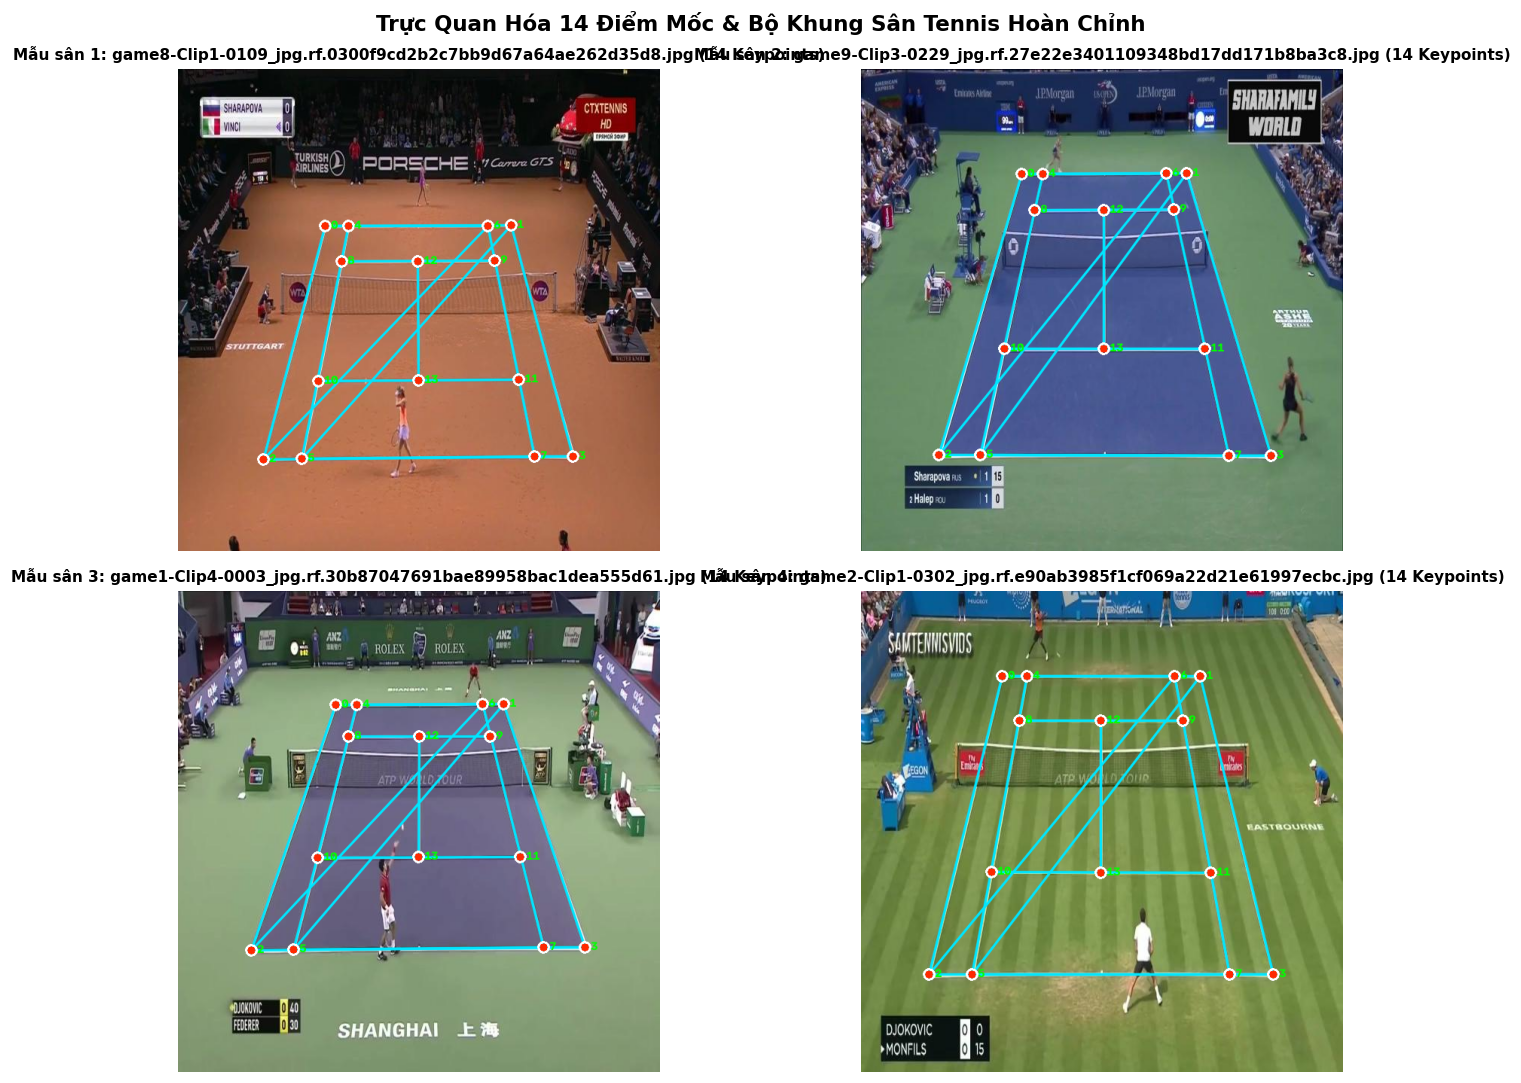

In [4]:
court_lines = [
    (0, 1), (1, 3), (3, 2), (2, 0),
    (4, 5), (5, 7), (7, 6), (6, 4),
    (0, 4), (1, 5), (2, 6), (3, 7),
    (8, 9), (10, 11), (12, 13)
]

def draw_court_on_image(img_path, kps_28):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    pts = []
    for i in range(14):
        x = int(kps_28[2 * i] * w)
        y = int(kps_28[2 * i + 1] * h)
        pts.append((x, y))
        
    for p1_idx, p2_idx in court_lines:
        if p1_idx < len(pts) and p2_idx < len(pts):
            p1, p2 = pts[p1_idx], pts[p2_idx]
            if p1 != (0, 0) and p2 != (0, 0):
                cv2.line(img_rgb, p1, p2, (0, 230, 255), 2, cv2.LINE_AA)
                
    for idx, (x, y) in enumerate(pts):
        if (x, y) != (0, 0):
            cv2.circle(img_rgb, (x, y), 5, (255, 40, 0), -1)
            cv2.circle(img_rgb, (x, y), 7, (255, 255, 255), 2)
            cv2.putText(img_rgb, str(idx), (x + 8, y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
    return img_rgb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

random.seed(100)
sample_entries = random.sample(data_json, 4)

for idx, entry in enumerate(sample_entries):
    full_img_p = os.path.join(court_dir, entry["id"])
    if not os.path.exists(full_img_p):
        for ext in [".jpg", ".png", ".jpeg"]:
            if os.path.exists(full_img_p + ext):
                full_img_p += ext
                break
                
    vis_img = draw_court_on_image(full_img_p, entry["kps"])
    if vis_img is not None:
        axes[idx].imshow(vis_img)
        axes[idx].set_title(f"Mẫu sân {idx+1}: " + os.path.basename(entry['id']) + " (14 Keypoints)", fontsize=10, fontweight="bold")
        axes[idx].axis('off')

plt.suptitle("Trực Quan Hóa 14 Điểm Mốc & Bộ Khung Sân Tennis Hoàn Chỉnh", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## 5. Trực Quan Hóa Tiền Xử Lý Tensor Cho ResNet50 (224x224 & Z-Score ImageNet)
Mô phỏng chính xác hàm `load_court_data` trong `training/train_court_line_detector_tf.py`:
1. Resize ảnh gốc về $(224, 224)$.
2. Co giãn tọa độ nhãn: $x_{\text{scaled}} = x_{\text{orig}} \times \frac{224}{W_{\text{orig}}}, \quad y_{\text{scaled}} = y_{\text{orig}} \times \frac{224}{H_{\text{orig}}}$.
3. Chuẩn hóa Z-Score ImageNet: $\text{Norm} = \frac{(\text{Img}/255.0 - \mu)}{\sigma}$.

📊 Kích thước Tensor đầu vào: (224, 224, 3)
📊 Vector nhãn Ground-truth (28 giá trị): (28,)


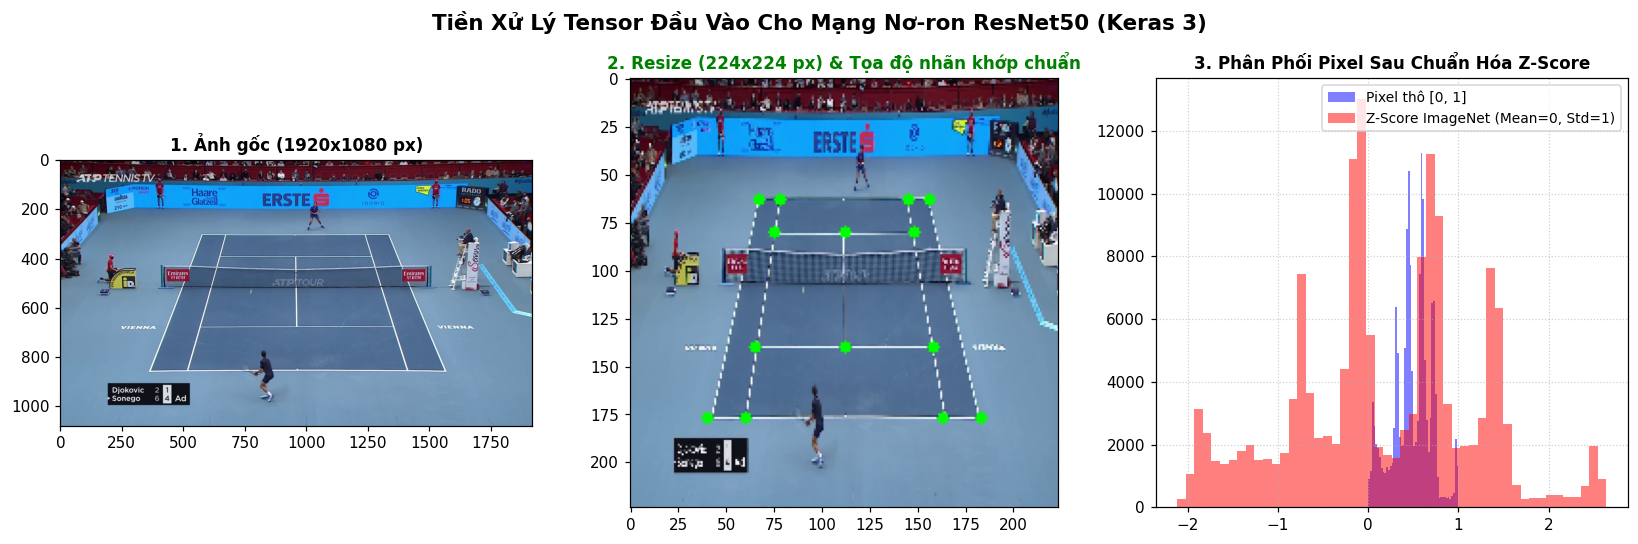

In [5]:
test_entry = data_json[15]
test_img_p = os.path.join(court_dir, test_entry["id"])
if not os.path.exists(test_img_p):
    test_img_p += ".jpg"

raw_bgr = cv2.imread(test_img_p)
raw_h, raw_w = raw_bgr.shape[:2]
img_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

resized_224 = cv2.resize(img_rgb, (224, 224))

kps_orig = np.array(test_entry["kps"], dtype=np.float32)
kps_224 = kps_orig.copy()
kps_224[::2] *= 224.0
kps_224[1::2] *= 224.0

vis_224 = resized_224.copy()
for i in range(14):
    kx, ky = int(kps_224[2 * i]), int(kps_224[2 * i + 1])
    if (kx, ky) != (0, 0):
        cv2.circle(vis_224, (kx, ky), 3, (0, 255, 0), -1)

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
normalized_tensor = ((resized_224.astype(np.float32) / 255.0) - mean) / std

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(f"1. Ảnh gốc ({raw_w}x{raw_h} px)", fontsize=11, fontweight="bold")
axes[0].axis('on')

axes[1].imshow(vis_224)
axes[1].set_title("2. Resize (224x224 px) & Tọa độ nhãn khớp chuẩn", fontsize=11, color="green", fontweight="bold")
axes[1].axis('on')

axes[2].hist((resized_224 / 255.0).ravel(), bins=50, color='blue', alpha=0.5, label='Pixel thô [0, 1]')
axes[2].hist(normalized_tensor.ravel(), bins=50, color='red', alpha=0.5, label='Z-Score ImageNet (Mean=0, Std=1)')
axes[2].set_title("3. Phân Phối Pixel Sau Chuẩn Hóa Z-Score", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Tiền Xử Lý Tensor Đầu Vào Cho Mạng Nơ-ron ResNet50 (Keras 3)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"📊 Kích thước Tensor đầu vào: {normalized_tensor.shape}")
print(f"📊 Vector nhãn Ground-truth (28 giá trị): {kps_224.shape}")

## 6. Trực Quan Hóa Hậu Xử Lý Sub-pixel Tinh Chỉnh Vạch Sơn Trắng (HSV Snapping)
Minh họa thuật toán trong `court_line_detector.py`:
- Chuyển sang không gian màu **HSV**.
- Tạo ngưỡng nhị phân lọc sắc trắng vạch sân (`cv2.inRange`).
- Áp dụng **Court Mask** loại trừ 100% khán đài và biển quảng cáo gây nhiễu.
- Tự động dời tọa độ thô vào tâm điểm giao nhau thực tế của vạch sân.

🎉 Hoàn tất toàn bộ quy trình trực quan hóa tiền xử lý dữ liệu vạch sân tennis!


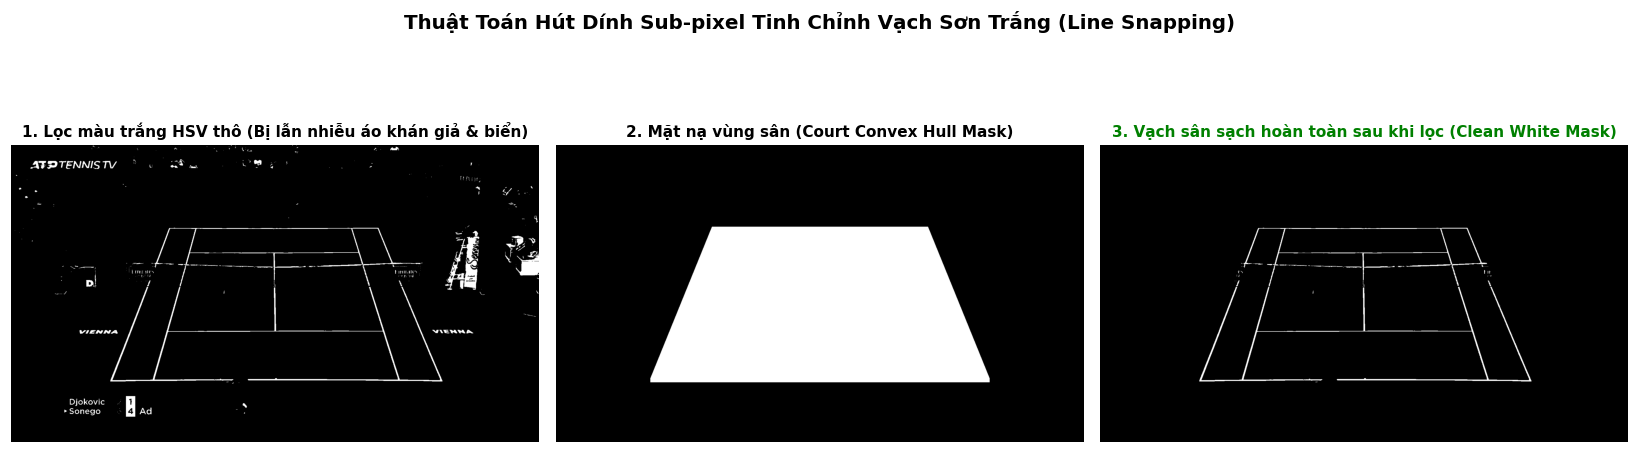

In [6]:
hsv = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2HSV)
lower_white = np.array([0, 0, 180])
upper_white = np.array([180, 50, 255])
raw_white_mask = cv2.inRange(hsv, lower_white, upper_white)

court_mask = np.zeros_like(raw_white_mask)
ch, cw = raw_bgr.shape[:2]

pts_court = np.array([(int(kps_orig[2 * i] * cw), int(kps_orig[2 * i + 1] * ch)) for i in range(14) if kps_orig[2 * i] > 0], dtype=np.int32)
if len(pts_court) >= 4:
    hull = cv2.convexHull(pts_court)
    cv2.fillConvexPoly(court_mask, hull, 255)
    kernel = np.ones((15, 15), np.uint8)
    court_mask = cv2.dilate(court_mask, kernel, iterations=1)
else:
    court_mask[int(ch * 0.2):int(ch * 0.95), int(cw * 0.1):int(cw * 0.9)] = 255

clean_white_mask = cv2.bitwise_and(raw_white_mask, court_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_white_mask, cmap='gray')
axes[0].set_title("1. Lọc màu trắng HSV thô (Bị lẫn nhiễu áo khán giả & biển)", fontsize=10, fontweight="bold")
axes[0].axis('off')

axes[1].imshow(court_mask, cmap='gray')
axes[1].set_title("2. Mặt nạ vùng sân (Court Convex Hull Mask)", fontsize=10, fontweight="bold")
axes[1].axis('off')

axes[2].imshow(clean_white_mask, cmap='gray')
axes[2].set_title("3. Vạch sân sạch hoàn toàn sau khi lọc (Clean White Mask)", fontsize=10, color="green", fontweight="bold")
axes[2].axis('off')

plt.suptitle("Thuật Toán Hút Dính Sub-pixel Tinh Chỉnh Vạch Sơn Trắng (Line Snapping)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("🎉 Hoàn tất toàn bộ quy trình trực quan hóa tiền xử lý dữ liệu vạch sân tennis!")